# Source-Only Train Sanity

This notebook loads the DAOD config from `configs/daod/`, runs a short source-only training job, and checks source-val plus target-val evaluation, then runs a few target predictions manually for visualization.

In [1]:
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import Visualizer

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src.data.daod import build_daod_dataset
from src.engine.daod_train_source import train_daod_source_only
from src.models.detrex_adapter import build_daod_model, run_daod_inference

CONFIG_PATH = REPO_ROOT / "configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml"
cfg = load_config(CONFIG_PATH)
cfg = deepcopy(cfg)
cfg.run.root_dir = '/home/ljzhang/code/SFADA/runs'
cfg.train.max_iter = 2
cfg.eval.source_val_limit = 20
cfg.eval.target_val_limit = 8
cfg


/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers",

{'seed': 42,
 'run': {'root_dir': '/home/ljzhang/code/SFADA/runs'},
 'data': {'root': '/home/ljzhang/data/ins-seg/cityscapes',
  'source_domain': 'cityscapes',
  'target_domain': 'foggy_cityscapes',
  'foggy_beta': '0.02',
  'num_classes': 8},
 'detector': {'model_name': 'dino_r50_4scale_12ep',
  'checkpoint_name': 'dino_r50_4scale_12ep_49_2AP.pth',
  'min_size_test': 800,
  'max_size_test': 1333},
 'train': {'batch_size': 2,
  'num_workers': 2,
  'lr': 0.0001,
  'weight_decay': 0.0001,
  'epochs': 1,
  'max_iter': 2,
  'log_period': 1,
  'checkpoint_period': 0,
  'max_to_keep': 10},
 'eval': {'batch_size': 2,
  'num_workers': 2,
  'source_val_limit': 20,
  'target_val_limit': 8}}

In [2]:
artifacts = train_daod_source_only(cfg)
artifacts


/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.039
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.031
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.023
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.078
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.037
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.048
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.020
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.048
 Average Recall     (AR) @[ IoU=0.50:0.

{'output_dir': '/home/ljzhang/code/SFADA/runs/daod_source/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep',
 'max_iter': 2,
 'source_val_metrics': OrderedDict([('bbox',
               {'AP': 2.7138754545819177,
                'AP50': 3.896025691960629,
                'AP75': 3.0858365186713663,
                'APs': 0.05217913399885479,
                'APm': 2.337547025203864,
                'APl': 7.780739271014553,
                'AP-person': 0.0,
                'AP-rider': 0.0,
                'AP-car': 21.71100363665534,
                'AP-truck': 0.0,
                'AP-bus': 0.0,
                'AP-train': 0.0,
                'AP-motorcycle': 0.0,
                'AP-bicycle': 0.0})]),
 'target_val_metrics': OrderedDict([('bbox',
               {'AP': 0.08075397237967777,
                'AP50': 0.17121552385641672,
                'AP75': 0.057912760291748355,
                'APs': 0.010783179789948928,
                'APm': 0.11855155604905991,
              

In [5]:
output_dir = Path(artifacts["output_dir"])
assert output_dir.exists()
assert (output_dir / "metrics.json").exists()
assert (output_dir / "source_val_metrics.json").exists()
assert (output_dir / "target_val_metrics.json").exists()
sorted(p.name for p in output_dir.iterdir())


['events.out.tfevents.1773358633.dev-dsk-ljzhang-2a-663ab0a7.us-west-2.amazon.com.56933.1',
 'last_checkpoint',
 'metrics.json',
 'model_0000001.pth',
 'model_final.pth',
 'source_val_coco.json',
 'source_val_eval',
 'source_val_metrics.json',
 'target_val_predictions.pt']

In [6]:
metrics_lines = (output_dir / "metrics.json").read_text(encoding="utf-8").strip().splitlines()
assert len(metrics_lines) > 0
metrics_lines[:3]


['{"data_time": 0.4665680350153707, "iteration": 0, "loss_bbox": 0.2167440801858902, "loss_bbox_0": 0.20912669599056244, "loss_bbox_1": 0.19951224327087402, "loss_bbox_2": 0.20188122987747192, "loss_bbox_3": 0.1964828073978424, "loss_bbox_4": 0.19952094554901123, "loss_bbox_dn": 0.1296985149383545, "loss_bbox_dn_0": 0.20084770023822784, "loss_bbox_dn_1": 0.15795683860778809, "loss_bbox_dn_2": 0.13751816749572754, "loss_bbox_dn_3": 0.12901125848293304, "loss_bbox_dn_4": 0.12960872054100037, "loss_bbox_enc": 0.27599769830703735, "loss_class": 1.0379334688186646, "loss_class_0": 1.0754331350326538, "loss_class_1": 1.1035977602005005, "loss_class_2": 1.0740301609039307, "loss_class_3": 1.078780174255371, "loss_class_4": 1.0736075639724731, "loss_class_dn": 1.1437420845031738, "loss_class_dn_0": 1.1521304845809937, "loss_class_dn_1": 1.1401349306106567, "loss_class_dn_2": 1.131417989730835, "loss_class_dn_3": 1.1484918594360352, "loss_class_dn_4": 1.1437122821807861, "loss_class_enc": 1.031

In [7]:
source_val_metrics = (output_dir / "source_val_metrics.json").read_text(encoding="utf-8")
source_val_metrics[:500]


'{"bbox": {"AP": 0.5089303164276898, "AP50": 0.9550837657472787, "AP75": 0.5527011852716357, "APs": 0.0, "APm": 1.072117264669299, "APl": 1.170791231070684, "AP-person": 0.03072721065209969, "AP-rider": 0.0, "AP-car": 3.9417054197793204, "AP-truck": 0.0, "AP-bus": 0.0, "AP-train": 0.09900990099009901, "AP-motorcycle": 0.0, "AP-bicycle": 0.0}}'

In [8]:
target_val_metrics = (output_dir / "target_val_metrics.json").read_text(encoding="utf-8")
target_val_metrics[:500]


(8,
 dict_keys(['sample_id', 'file_name', 'scores', 'pred_classes', 'pred_boxes']))

In [9]:
adapter = build_daod_model(cfg, load_weights=False)
checkpoint_path = output_dir / "model_final.pth"
adapter.model.load_state_dict(torch.load(checkpoint_path, map_location="cpu", weights_only=False)["model"], strict=False)

target_ds = build_daod_dataset(cfg, "target_val", transform=None)
samples = [target_ds[i] for i in range(2)]
outputs = run_daod_inference(adapter, samples)
len(outputs)


2

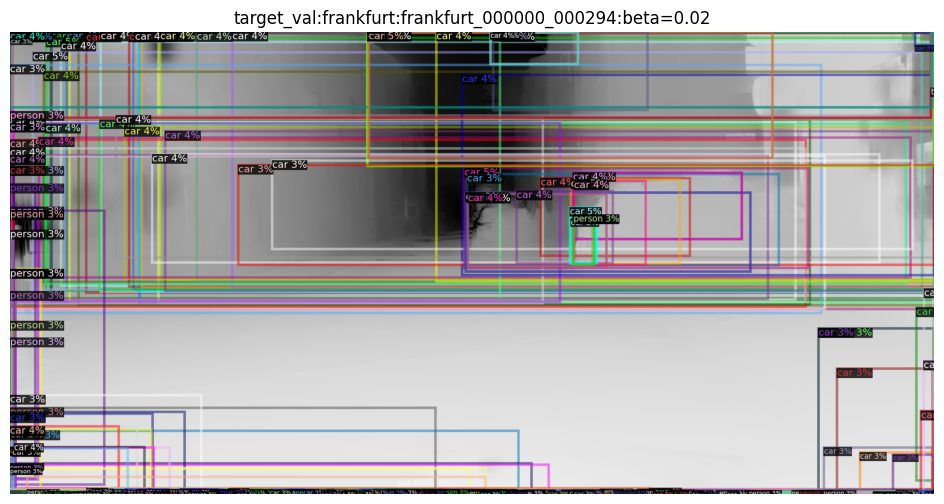

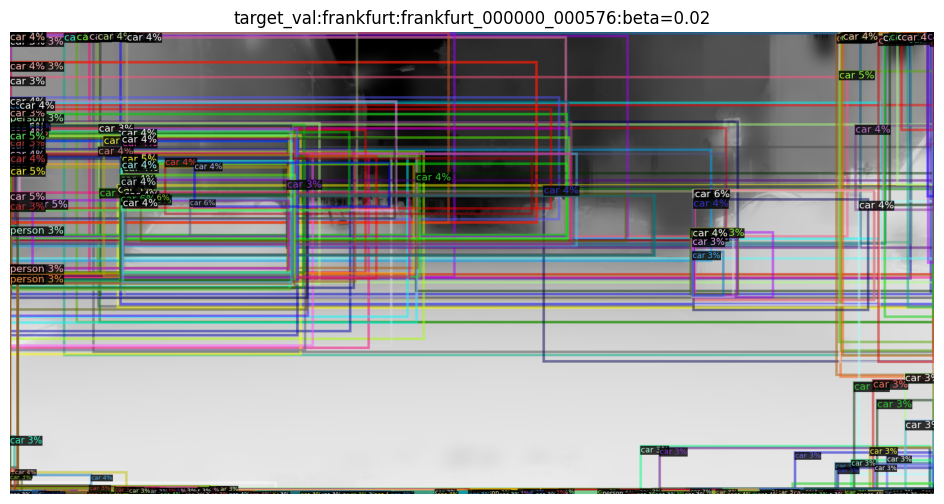

In [10]:
metadata = MetadataCatalog.get("daod_source_train_sanity")
metadata.set(thing_classes=list(target_ds.thing_classes))

def visualize(sample, output, title):
    image = np.asarray(Image.open(sample["file_name"]).convert("RGB"))
    vis = Visualizer(image, metadata=metadata)
    rendered = vis.draw_instance_predictions(output["prediction"]["instances"].to("cpu")).get_image()
    plt.figure(figsize=(12, 6))
    plt.imshow(rendered)
    plt.title(title)
    plt.axis("off")


for sample, output in zip(samples, outputs):
    visualize(sample, output, sample["sample_id"])
